# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** Marcus Chan

**SFU ID:** 301455991

**Date:** June 24 2026

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [3]:
df_ab = pd.read_csv('phigma_ab_study.csv')

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NaN,5,1,1,0,38,17.91


In [4]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,1323,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,EU,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,593,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [5]:
# Missing values
df_ab.isnull().sum()


user_id                                  0
ab_group                                 0
device_type                              0
account_age_days                         0
prior_whiteboard_sessions                0
plan_region                            677
num_collaborators                        0
feature_tour_completed                   0
templates_used                           0
ai_suggestions_used                      0
whiteboard_actions_per_session           0
avg_whiteboard_session_duration_min      0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


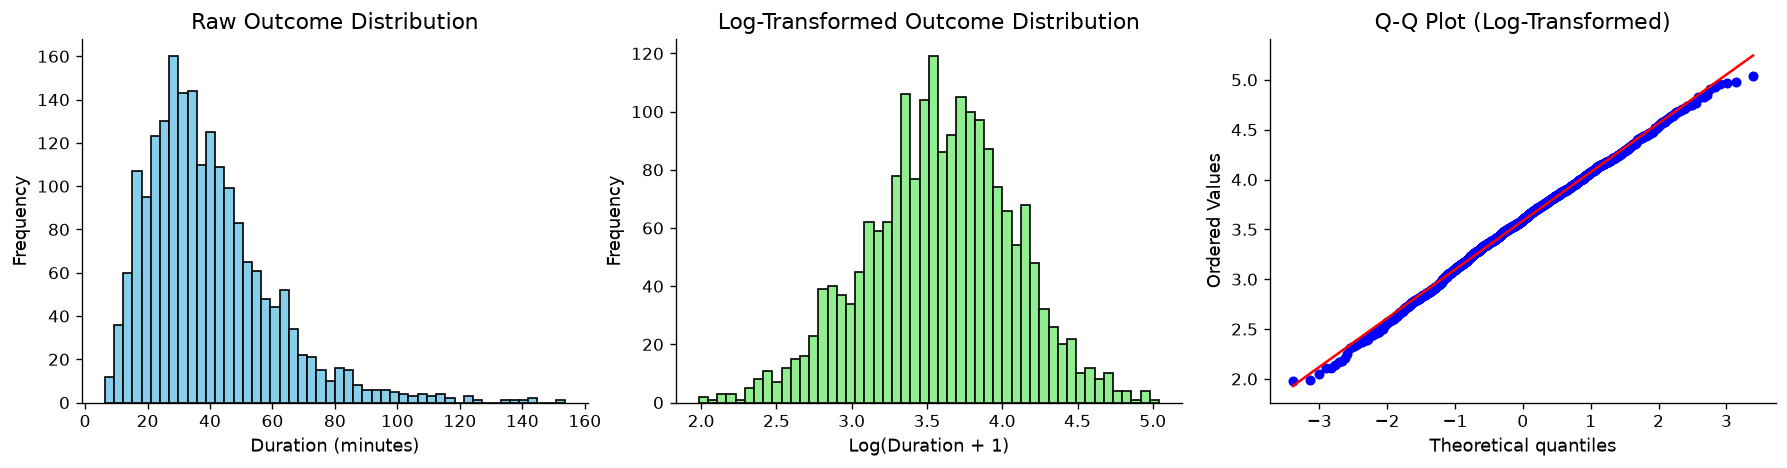

Skewness (raw):             1.3758
Skewness (log-transformed): -0.1627


In [ ]:
# BEGIN
# Load target outcome variable
outcome = df_ab['avg_whiteboard_session_duration_min']

# // 1. Normality & Transformation Visualizations
# Initialize three-panel visual layout
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Draw histogram of raw outcome distribution
axes[0].hist(outcome, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Raw Outcome Distribution')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Frequency')

# Transform outcome variable using natural logarithm
log_outcome = np.log(outcome + 1)  # avoiding log(0)

# Draw histogram of log-transformed outcome distribution
axes[1].hist(log_outcome, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Log-Transformed Outcome Distribution')
axes[1].set_xlabel('Log(Duration + 1)')
axes[1].set_ylabel('Frequency')

# Draw Q-Q plot comparing log-transformed distribution to a normal distribution
stats.probplot(log_outcome, dist='norm', plot=axes[2])
axes[2].lines[0].set_markersize(3)
axes[2].set_title('Q-Q Plot (Log-Transformed)')

# Render visualizations
plt.tight_layout()
plt.show()

# // 2. Statistical Diagnostics
# Compute and output skewness for both raw and log-transformed distributions
raw_skew = stats.skew(outcome)
log_skew = stats.skew(log_outcome)
print(f"Skewness (raw):             {raw_skew:.4f}")
print(f"Skewness (log-transformed): {log_skew:.4f}")
# END

**✏️ Your interpretation (A1.1):**

**Is the log-transformed outcome more normally distributed?**

Yes, The log-transformed skewness is much more symmetrical.


**How does the Q-Q plot support your conclusion?**

The dots match the line meaning the data is following the expected normal distribution after being transformed

**Will you use the raw or log outcome in your model?**

I will use the log outcome


#### A1.2 — Examine the confounders

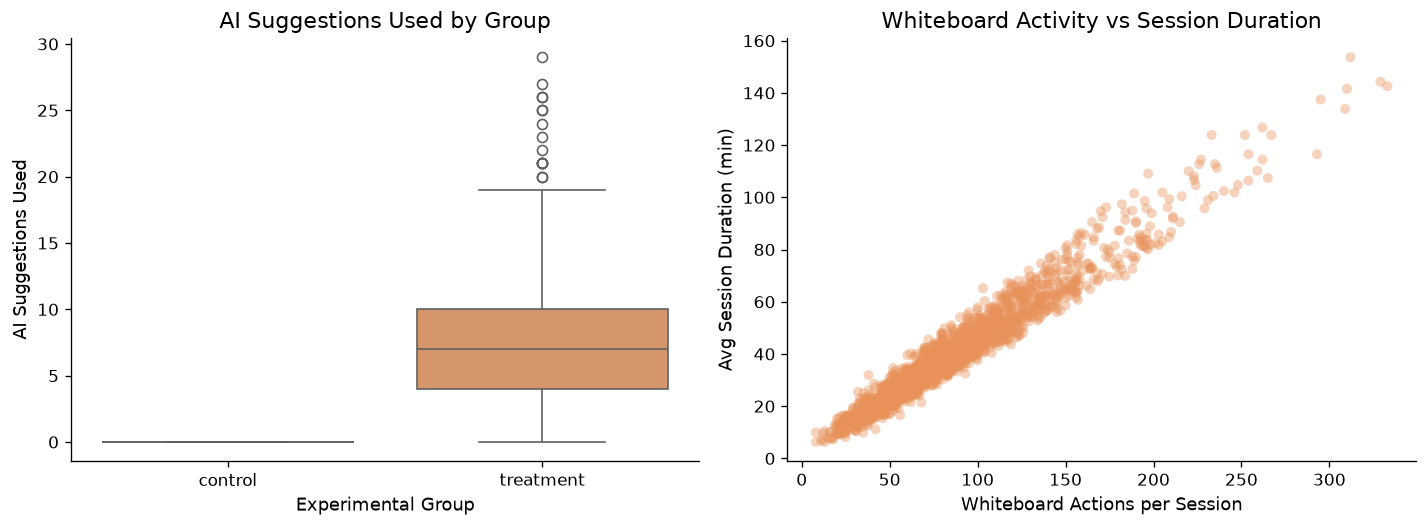

Correlation (whiteboard_actions_per_session vs avg_whiteboard_session_duration_min): 0.9737

ai_suggestions_used by ab_group:
            count      mean       std  min  25%  50%   75%   max
ab_group                                                        
control    1011.0  0.000000  0.000000  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.334681  4.550684  0.0  4.0  7.0  10.0  29.0


In [103]:
# BEGIN
# Load AB testing dataset
# (df_ab already loaded)

# // 1. Visual Exploratory Data Analysis
# Initialize side-by-side visualization layouts
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Draw boxplot comparison of AI suggestion usage across experimental groups
sns.boxplot(data=df_ab, x='ab_group', y='ai_suggestions_used', ax=axes[0], color=ACCENT)
axes[0].set_title('AI Suggestions Used by Group')
axes[0].set_xlabel('Experimental Group')
axes[0].set_ylabel('AI Suggestions Used')

# Draw scatter plot comparing whiteboard activity density against session durations
axes[1].scatter(df_ab['whiteboard_actions_per_session'], df_ab['avg_whiteboard_session_duration_min'],
                alpha=0.4, color=ACCENT, edgecolor='none')
axes[1].set_title('Whiteboard Activity vs Session Duration')
axes[1].set_xlabel('Whiteboard Actions per Session')
axes[1].set_ylabel('Avg Session Duration (min)')

# Optimize layout and display visualizations
plt.tight_layout()
plt.show()

# // 2. Statistical Analysis
# Calculate and print the correlation between whiteboard activity and session duration
corr = df_ab['whiteboard_actions_per_session'].corr(df_ab['avg_whiteboard_session_duration_min'])
print(f"Correlation (whiteboard_actions_per_session vs avg_whiteboard_session_duration_min): {corr:.4f}")

# Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
print("\nai_suggestions_used by ab_group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe())
# END


**✏️ Your interpretation (A1.2):**

**What do you notice about `ai_suggestions_used` across the two groups?**

The control is blank because that group was not given access to AI suggestions


**What does the correlation between `whiteboard_actions_per_session` and the outcome suggest?**

Users make more actions as the time passes.


**Why should neither be included in your model?**

Both do not produce any information worth using as the information is redundant. We want information that will help us show if the AI assistant increases time spent on the whiteboard


#### A1.3 — Predictor distributions and relationships with outcome

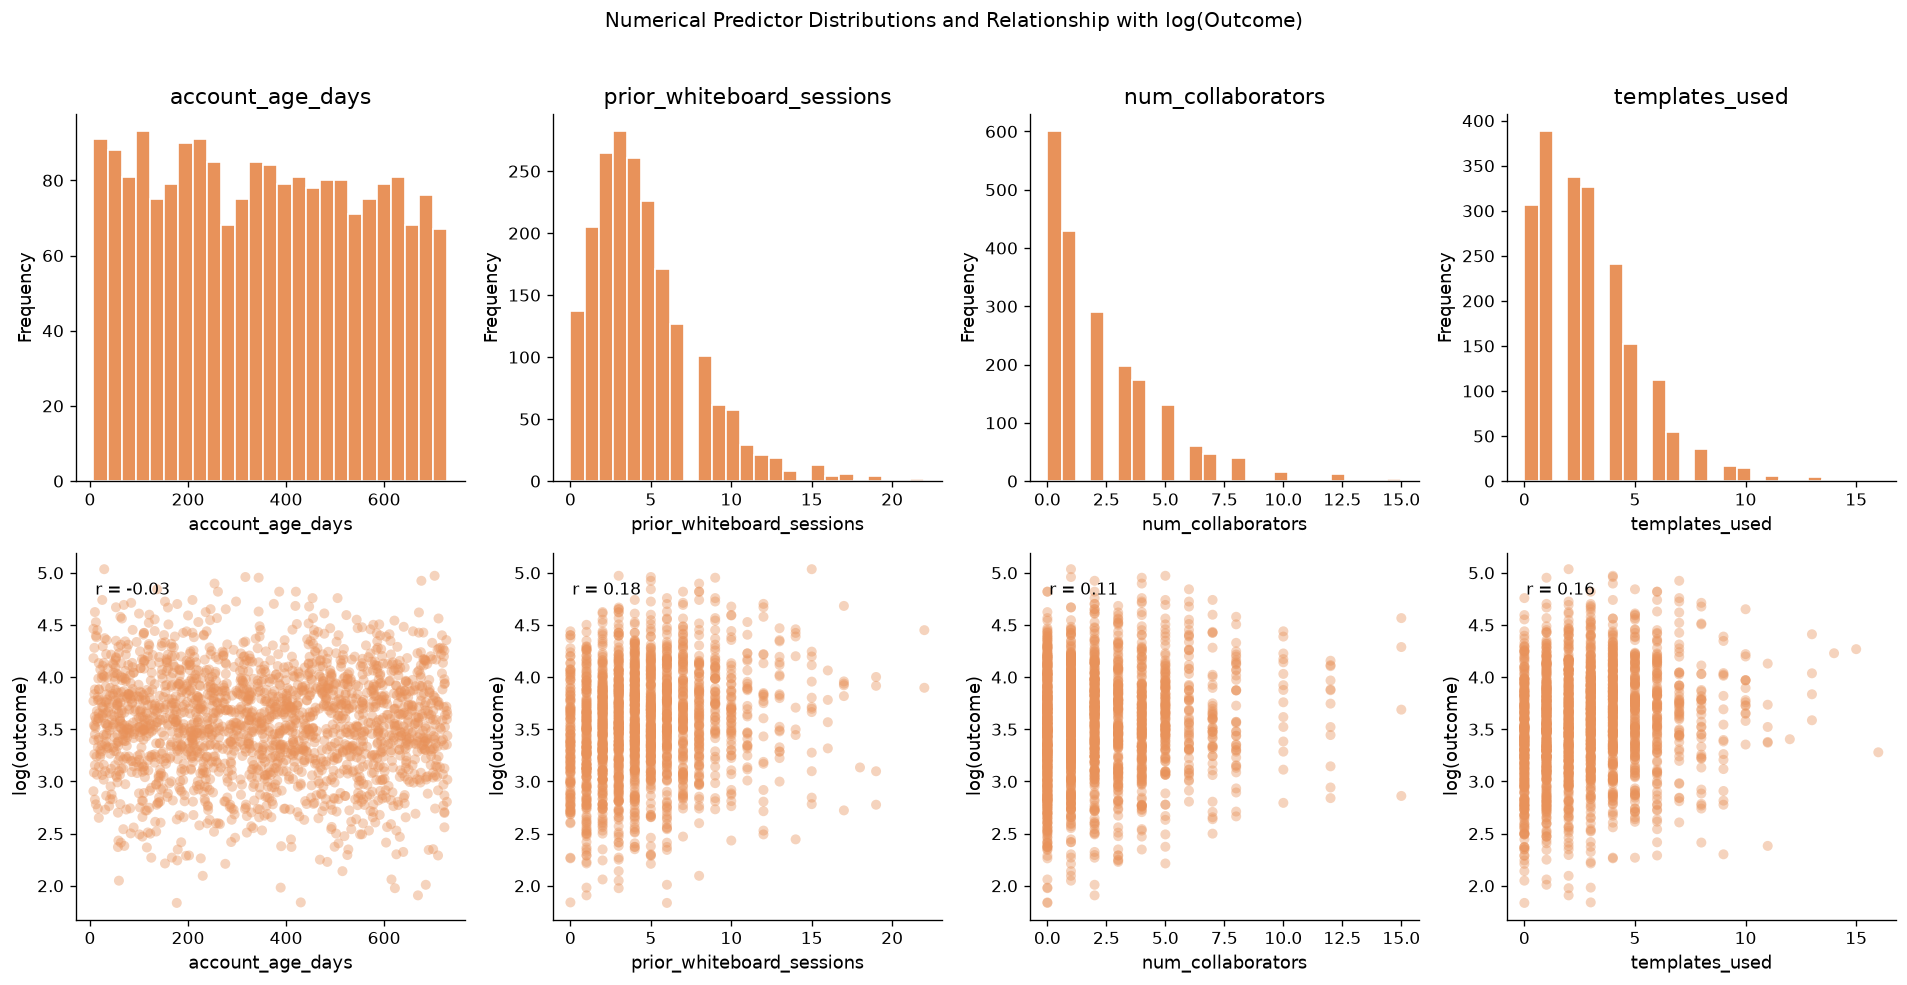

In [104]:
# BEGIN
# Define list of numerical predictor variables
numerical_predictors = ['account_age_days', 'prior_whiteboard_sessions', 'num_collaborators', 'templates_used']

# Compute log-transformed outcome variable
log_outcome = np.log(df_ab['avg_whiteboard_session_duration_min'])

# Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)
fig, axes = plt.subplots(2, len(numerical_predictors), figsize=(4 * len(numerical_predictors), 8))

# FOR each predictor variable:
for i, col in enumerate(numerical_predictors):
    # // Top row: Univariate Analysis
    # Draw histogram to show distribution of the predictor
    axes[0, i].hist(df_ab[col], bins=25, color=ACCENT, edgecolor='white')
    axes[0, i].set_title(col)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')

    # // Bottom row: Bivariate Analysis
    # Draw scatter plot comparing predictor against log-transformed outcome
    axes[1, i].scatter(df_ab[col], log_outcome, alpha=0.4, color=ACCENT, edgecolor='none')
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('log(outcome)')

    # Calculate correlation coefficient between predictor and log-transformed outcome
    r = df_ab[col].corr(log_outcome)

    # Annotate plot with correlation coefficient
    axes[1, i].text(0.05, 0.92, f'r = {r:.2f}', transform=axes[1, i].transAxes,
                    fontsize=10, verticalalignment='top')
# END FOR

# Add global title and render layout
fig.suptitle('Numerical Predictor Distributions and Relationship with log(Outcome)', y=1.02)
plt.tight_layout()
plt.show()
# END


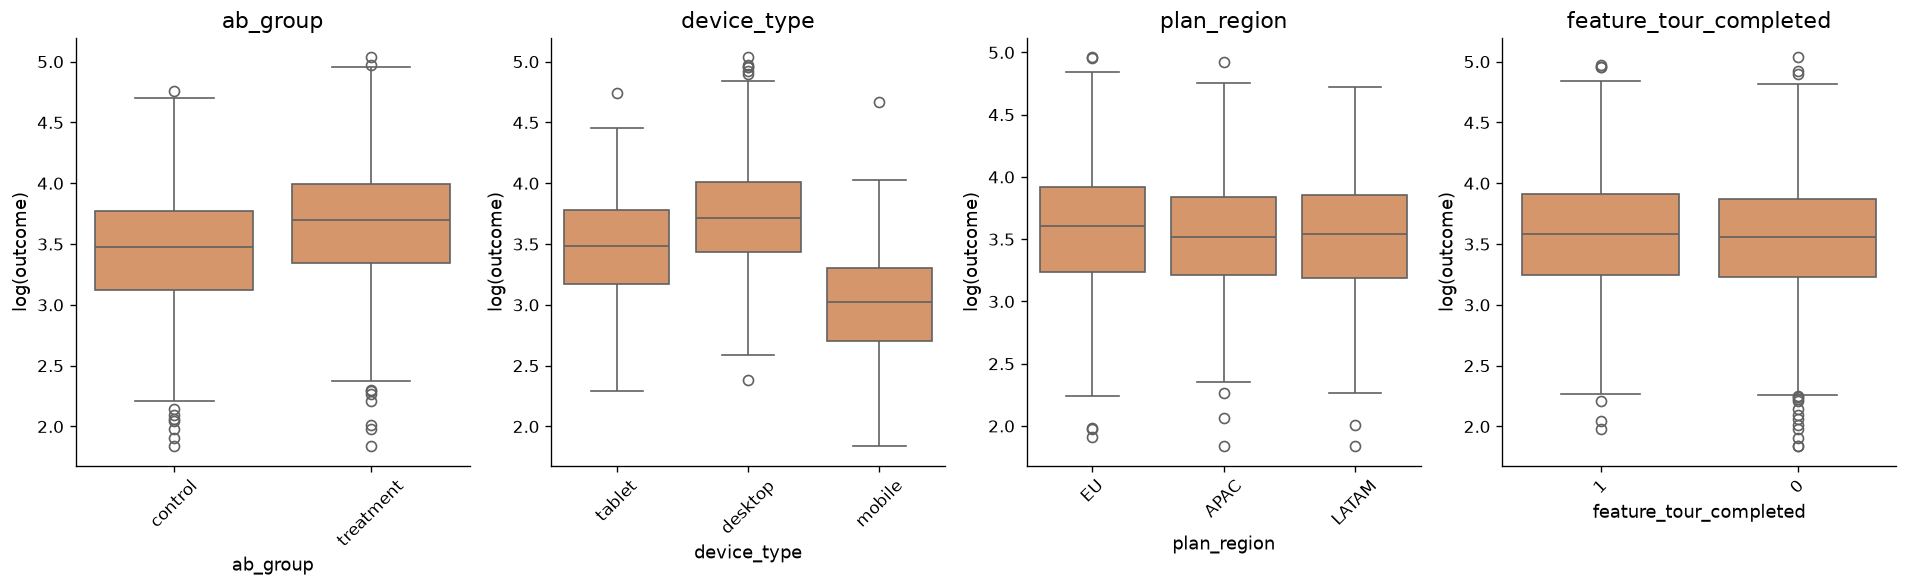

In [105]:
# BEGIN
# Define list of categorical predictor variables
categorical_predictors = ['ab_group', 'device_type', 'plan_region', 'feature_tour_completed']

# Initialize visual grid layout (1 row by N columns, where N is the number of categories)
fig, axes = plt.subplots(1, len(categorical_predictors), figsize=(4 * len(categorical_predictors), 5))

# FOR each categorical variable:
for i, col in enumerate(categorical_predictors):
    # Retrieve unique category levels
    levels = df_ab[col].dropna().unique()

    # Group log-transformed outcome values by category levels
    plot_df = pd.DataFrame({col: df_ab[col], 'log_outcome': log_outcome})

    # Draw boxplots of log-transformed outcome grouped by category level
    sns.boxplot(data=plot_df, x=col, y='log_outcome', ax=axes[i], color=ACCENT, order=levels)

    # Rotate category axis labels for readability
    axes[i].tick_params(axis='x', rotation=45)

    # Label axis and set titles
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(outcome)')
    axes[i].set_title(col)
# END FOR

# Render layout
plt.tight_layout()
plt.show()
# END


**✏️ Your interpretation (A1.3):**

**3–5 sentences summarizing your EDA. Which predictors look most promising?Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?**

Among the numerical predictors, `prior_whiteboard_sessions` (r = 0.18) and `templates_used` (r = 0.16) show the strongest associations with log-session-duration, while `account_age_days` (r = −0.03) shows essentially none.


The count-based predictors, `prior_whiteboard_sessions`, `num_collaborators`, and `templates_used`, are visibly right-skewed and will be log(x+1)-transformed before modeling, whereas `account_age_days` is roughly uniform and needs no transformation.

Of the different categories, `device_type` makes the biggest difference, mobile users have noticeably shorter sessions than tablet or desktop users. `ab_group` also makes a difference: treatment users have longer sessions than control users, which is the effect this analysis is trying to measure. `plan_region` and `feature_tour_completed`, on the other hand, look about the same across their groups, so they are probably less useful.


 I'm excluding `ai_suggestions_used` and `whiteboard_actions_per_session` from the model because both sit on the causal pathway between treatment and outcome rather than acting as independent, pre-treatment predictors.

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [106]:
# BEGIN
# Load baseline dataset
# (df_ab already loaded)

# // 1. Encode Categorical Variables
# Convert experimental group ('ab_group') into a binary integer indicator
ab_group_enc = (df_ab['ab_group'] == 'treatment').astype(int)

# Generate dummy indicators (one-hot encoding) for device types, omitting the first category
device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device', drop_first=True)

# Generate dummy indicators (one-hot encoding) for regions, omitting the first category
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region', drop_first=True)

# // 2. Perform Optional Transformations
# Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values
log_prior_sessions = np.log1p(df_ab['prior_whiteboard_sessions'])
log_num_collaborators = np.log1p(df_ab['num_collaborators'])
log_templates_used = np.log1p(df_ab['templates_used'])

# // 3. Assemble Modeling Dataset
# Merge numerical characteristics, binary groups, and dummy indicators into matrix X
X = pd.concat([
    df_ab[['account_age_days', 'feature_tour_completed']],
    log_prior_sessions.rename('log_prior_whiteboard_sessions'),
    log_num_collaborators.rename('log_num_collaborators'),
    log_templates_used.rename('log_templates_used'),
    ab_group_enc.rename('ab_group_enc'),
    device_dummies,
    region_dummies
], axis=1)

# Set target vector y as the log-transformed outcome variable
y = np.log(df_ab['avg_whiteboard_session_duration_min'])

# // 4. Quality Control
# Verify that there are no missing (null) values in feature matrix X
print(f"Any missing values in X: {X.isnull().any().any()}")

# Inspect matrix dimensions and print a preview of the processed data
print(f"X shape: {X.shape}")
X.head(3)
# END


Any missing values in X: False
X shape: (2000, 10)


,account_age_days,feature_tour_completed,log_prior_whiteboard_sessions,log_num_collaborators,log_templates_used,ab_group_enc,device_mobile,device_tablet,region_EU,region_LATAM
0,478,1,1.609438,1.386294,0.000000,0,False,True,True,False
1,633,0,2.302585,0.693147,0.693147,0,False,False,False,False
2,159,1,2.397895,1.791759,0.693147,0,False,False,False,False


**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*

**✏️ Your interpretation (A2):**

- `account_age_days`: included raw (no transformation) since it's the user's tenure on the platform, a plausible driver of session length, and its distribution was roughly uniform rather than skewed.
- `feature_tour_completed`: included as a raw binary indicator since completing onboarding likely signals greater familiarity and intent to engage with the whiteboard.
- `log_prior_whiteboard_sessions`: log(x+1)-transformed because the raw count was right-skewed; included since prior usage frequency is a natural predictor of how long a user engages now.
- `log_num_collaborators`: log(x+1)-transformed for the same right-skew reason; included because collaborative sessions plausibly run longer than solo ones.
- `log_templates_used`: log(x+1)-transformed for right-skew; included as a proxy for how actively a user is building content, which should extend session time.
- `ab_group_enc`: binary encoding of the experimental treatment indicator (1 = treatment, 0 = control), the key variable of interest for the research question.
- `device_mobile`, `device_tablet`: one-hot encoded from `device_type` (desktop dropped as the reference category) to capture device-driven differences in session length, since smaller screens or touch input likely constrain how long someone stays on the whiteboard.
- `region_EU`, `region_LATAM`: one-hot encoded from `plan_region` (APAC dropped as the reference category) to control for regional differences in usage patterns; rows with missing region are implicitly absorbed into the reference category.



### A3 — OLS Regression


In [107]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X = X.astype(float)
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.365
Model:                                             OLS   Adj. R-squared:                  0.362
Method:                                  Least Squares   F-statistic:                     114.4
Date:                                 Mon, 29 Jun 2026   Prob (F-statistic):          4.38e-188
Time:                                         17:31:49   Log-Likelihood:                -1017.1
No. Observations:                                 2000   AIC:                             2056.
Df Residuals:                                     1989   BIC:                             2118.
Df Model:                                           10                                         
Covariance Type:                             nonrobust                                         
                                    coef

#### A3.1 — Interpret the model

In [108]:
# BEGIN
# Input trained OLS regression model
# (model_ols already fit)
# Input experimental dataframe
# (df_ab already loaded)

# // 1. Evaluate Model Fit
# Display model's R-squared value to assess variance explained
print(f"R-squared: {model_ols.rsquared:.4f}")

# // 2. Analyze Treatment Effect
# Extract coefficient and significance (p-value) for the A/B testing variable
treatment_coef = model_ols.params['ab_group_enc']
treatment_pval = model_ols.pvalues['ab_group_enc']

# Convert the log-space treatment coefficient back to its scale in physical time (minutes)
pct_change = (np.exp(treatment_coef) - 1) * 100
mean_duration = df_ab['avg_whiteboard_session_duration_min'].mean()
minutes_effect = (np.exp(treatment_coef) - 1) * mean_duration

# Display treatment effect size and statistical significance
print(f"\nTreatment effect (ab_group_enc):")
print(f"  Coefficient (log scale): {treatment_coef:.4f}")
print(f"  p-value:                 {treatment_pval:.4g}")
print(f"  Implied change:          {pct_change:.2f}%  (~{minutes_effect:.2f} minutes at the average session length)")

# // 3. Extract Significant Predictors
# Filter all model coefficients where p-value < 0.05
significant = model_ols.pvalues[model_ols.pvalues < 0.05].index

# FOR each significant variable:
print("\nSignificant predictors (p < 0.05):")
for var in significant:
    coef = model_ols.params[var]
    pval = model_ols.pvalues[var]
    # Display variable name, its directional coefficient, and its p-value
    direction = 'positive' if coef > 0 else 'negative'
    print(f"  {var:30s} coef={coef:+.4f} ({direction})  p={pval:.4g}")
# END FOR
# END


R-squared: 0.3651

Treatment effect (ab_group_enc):
  Coefficient (log scale): 0.1766
  p-value:                 5.747e-19
  Implied change:          19.31%  (~7.64 minutes at the average session length)

Significant predictors (p < 0.05):
  const                          coef=+3.2345 (positive)  p=0
  feature_tour_completed         coef=+0.0556 (positive)  p=0.002467
  log_prior_whiteboard_sessions  coef=+0.1426 (positive)  p=1.273e-24
  log_num_collaborators          coef=+0.0900 (positive)  p=1.162e-12
  log_templates_used             coef=+0.0808 (positive)  p=9.122e-08
  ab_group_enc                   coef=+0.1766 (positive)  p=5.747e-19
  device_mobile                  coef=-0.7232 (negative)  p=3.804e-140
  device_tablet                  coef=-0.2536 (negative)  p=4.234e-31
  region_LATAM                   coef=-0.0598 (negative)  p=0.04337


**✏️ Results paragraph (A3):**


**Write a results paragraph as if reporting in a research paper. Include:**
- **The treatment effect estimate and its significance**
- **R² and what it tells you about model fit**
- **At least two other notable predictors and their direction**
- **Whether the AI assistant's effect is practically meaningful (not just statistically significant)**


The OLS model estimated a treatment effect of β = 0.1766 on log(session duration) (p = 5.75 × 10⁻¹⁹), 
indicating that access to the AI assistant is associated with an approximate 19.31% increase in 
average whiteboard session duration, equivalent to roughly 7.64 additional minutes per session for a 
typical user (relative to an overall average of ~39.5 minutes). This effect was statistically 
significant well beyond the 0.05 threshold. The model explained R² = 0.365 of the variance in 
log(session duration), suggesting that treatment assignment and the included covariates account for 
a substantial, though far from complete, share of the variation in engagement, with the remaining 
~63.5% attributable to unmeasured factors such as individual user motivation or context of use. 
Among the other significant predictors, device type had the largest effect: mobile users had 
substantially shorter sessions than desktop users (coef = -0.7232, p < 0.001), an effect even larger 
in magnitude than the AI treatment itself, suggesting device constraints (screen size, input method) 
dominate engagement more than any single feature. `log_prior_whiteboard_sessions` was also positively 
associated with session length (coef = 0.1426, p < 0.001), consistent with more experienced, 
habitual users engaging more deeply with each session. Practically, a ~19% increase, nearly 8 extra 
minutes per session, is a meaningful improvement, not merely a statistically detectable one: given 
the large sample size (n = 2000), even trivial effects would reach significance, but an effect of this 
magnitude is comparable to switching a meaningful share of mobile users onto desktop, indicating the 
AI assistant meaningfully changes user behavior rather than producing a negligible but "significant" 
artifact of sample size.






#### A3.2 — Regression diagnostics

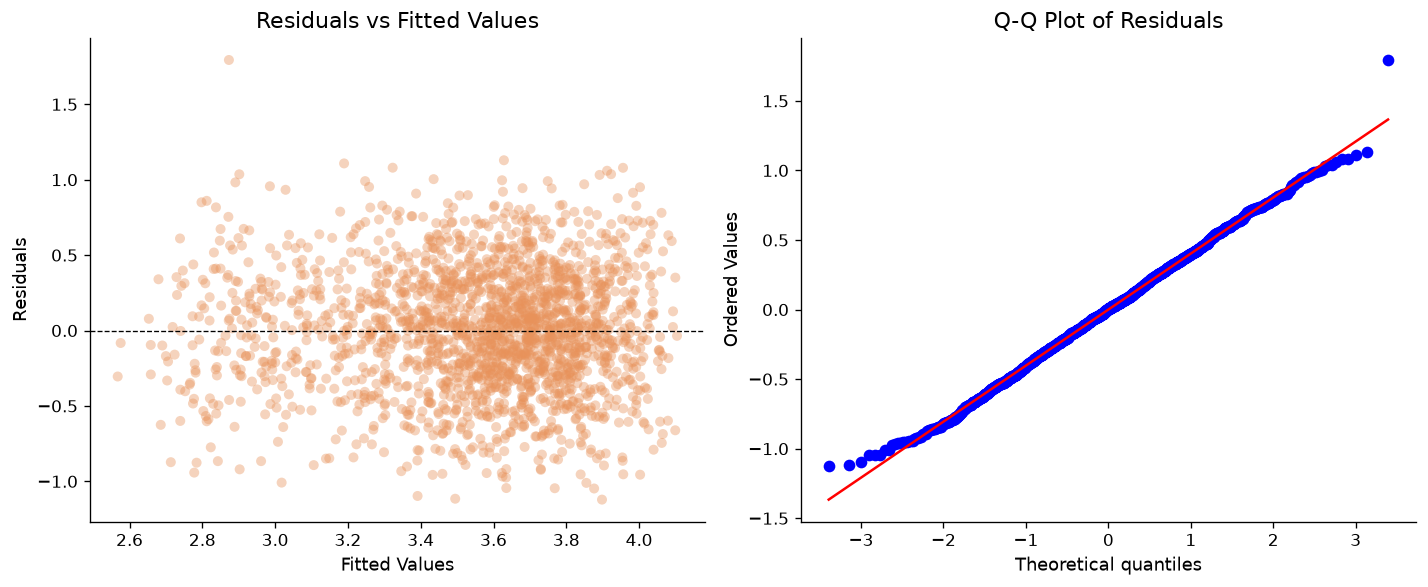

In [109]:
# BEGIN
# Extract predictions and error terms (residuals) from regression model
fitted_vals = model_ols.fittedvalues
residuals = model_ols.resid

# Initialize a side-by-side diagnostic visualization layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# // Check for uniform variance (homoscedasticity)
# Draw scatter plot of prediction values vs residuals
axes[0].scatter(fitted_vals, residuals, alpha=0.4, color=ACCENT, edgecolor='none')

# Overlay a horizontal zero-error baseline reference line
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# // Check for normality of errors
# Draw a Q-Q plot of residuals against a normal theoretical distribution
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Render diagnostic plots
plt.tight_layout()
plt.show()
# END


**✏️ Your interpretation (A3.2):**

**Do the residuals look randomly scattered around zero?**

Yes, the points are spread evenly above and below the zero line with no funnel shape, so the model's 
variance looks consistent across fitted values.

**Does the Q-Q plot suggest normally distributed errors?**

Mostly. The points follow the diagonal line closely in the middle, but there's a slight deviation at 
the tails, especially one point in the upper right that sits above the line.

**Note any patterns that concern you.**

Just one outlier (fitted value around 2.9, residual around 1.8) shows up in both plots. Other than 
that, there's no clear pattern or curve that would suggest a problem with the model.


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*


In [110]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())


In [111]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines


**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*


---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [112]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                           str
signup_date                       str
first_session_date                str
device_type                       str
country_tier                      str
referral_source                   str
num_sessions_30d                int64
total_time_min_30d              int64
projects_created_30d            int64
exports_30d                     int64
collaborators_invited_30d       int64
support_tickets_30d             int64
used_premium_feature_preview    int64
ai_assistant_sessions_30d       int64
subscribed                      int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [113]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [114]:
# YOUR CODE HERE

# 1. Parse dates
# df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
# df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
# df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
# df_sub['avg_session_duration_min'] = ...

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
# df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
# device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
# referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)
# y_sub = df_sub['subscribed']

# Confirm
# print(f"Any inf: {np.isinf(X_sub.values).any()}")
# print(f"Any NaN: {X_sub.isnull().any().any()}")
# print(f"Feature matrix shape: {X_sub.shape}")
# X_sub.head(3)


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*


### B2 — EDA for Subscription


In [115]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


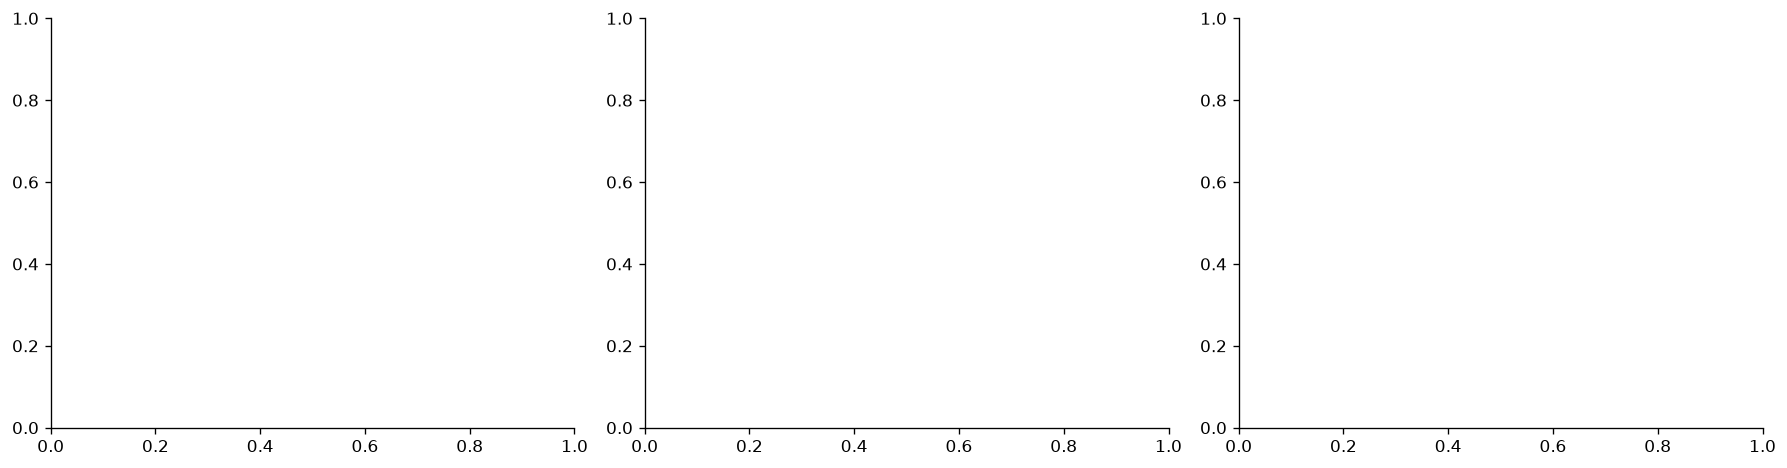

In [116]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
# axes[0]: ...

# Plot 2 — YOUR CODE
# axes[1]: ...

# Plot 3 — YOUR CODE
# axes[2]: ...

plt.tight_layout()
plt.show()


In [117]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [118]:
# YOUR CODE HERE
# X_const_sub = sm.add_constant(X_sub)
# model_logit = sm.Logit(y_sub, X_const_sub).fit()
# print(model_logit.summary())


In [119]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# odds_ratios = np.exp(model_logit.params)
# conf_int    = np.exp(model_logit.conf_int())
# Combine into a readable table and display
# Filter to significant only: p < 0.05


In [120]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*


### B4 — Logistic Regression with sklearn (Predictive)


In [121]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


In [122]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


In [123]:
# YOUR CODE HERE
# Confusion matrix heatmap
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
# fig, ax = plt.subplots(figsize=(5, 4))
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.title('Logistic Regression — Confusion Matrix')
# plt.show()


In [124]:
# YOUR CODE HERE
# Classification report
# print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


In [125]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8)
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve — Logistic Regression')
# ax.legend()
# plt.show()


**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [126]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


In [127]:
# YOUR CODE HERE
# Confusion matrix


In [128]:
# YOUR CODE HERE
# Classification report + ROC-AUC


In [129]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)


### C3 — Model Comparison


In [130]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)


In [131]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [132]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
